# WallTrack: 4D segmentation & cell-wall deconstruction map (demo dataset)

Reproduction of the pipeline from:

> Refahi, Y., et al. **"Plant cell wall enzymatic deconstruction: Bridging the gap between micro and nano scales."**
> *Bioresource Technology* (2024), doi:[10.1016/j.biortech.2024.131551](https://doi.org/10.1016/j.biortech.2024.131551) — preprint [bioRxiv 2024.01.11.575220v1](https://www.biorxiv.org/content/10.1101/2024.01.11.575220v1).

**Author code:** WallTrack, GitLab `farelab/teamyr/publications/refahi_et_al_4d`, pinned commit `c9df0f056432ca7e442d9391372f7ee4fdbbb2ba`.
**Data:** author-provided `demo_dataset.zip` (2 confocal stacks: before/during hydrolysis), fetched *inside this notebook*.

**Scope (partial demonstration):** on the 2-time-point demo dataset only — (1) empty-slice removal and seeded 3D watershed segmentation of the pre-hydrolysis stack (`segment_t0.py` flow), (2) rigid→affine→vector-field block-matching registration and segmentation propagation (`segment_all.py` flow), (3) voxel-scale deconstruction map (`computeDeconstructionMap.py` procedure) rendered with matplotlib. The paper's 24 h time-lapses, enzyme-loading series, and statistical quantification are **not** included (data not public).

**このノートブックについて:** WallTrack（著者提供の4Dコンフォカル分割・トラッキングソフト）をデモデータセット上で実行し、酵素分解前後の細胞壁セグメンテーション伝播とボクセル分解マップを再現します。完全な再現ではなく、著者公開の2時点デモデータによる部分デモンストレーションです。

**AI-assisted orchestration notice / AI支援の明示:** The WallTrack scripts are run **unchanged from the pinned author commit**; the notebook only supplies installation, configuration (the wiki-documented `dataNames.py` edit), orchestration, and matplotlib visualization. The deconstruction-map rendering replaces the authors' BioModLab GUI viewer — it is an **ADAPTED PYTHON DEMONSTRATION** of the same computation, not author-endorsed code.


## Runtime selection — select **CPU** runtime (no GPU required)

WallTrack is classical 3D image processing (C++ `vt` library via Python); it uses **no CUDA/GPU**. A standard **CPU runtime** is correct. The authors' wiki states the demo dataset runs in **< 5 minutes** on a normal computer (16–32 GB RAM); on the free Colab CPU runtime expect ~15–35 min end-to-end including the conda environment setup (~5–10 min) and downloads (~50 MB conda packages + demo dataset).

**Run all:** `ランタイム` → `すべてのセルを実行`. The notebook installs its own miniforge environment under `/content`; no Drive mount, no credentials.

**ランタイムの選択:** GPUは不要です。**CPUランタイム**を選択して「すべてのセルを実行」してください。依存関係はノートブック内で構築されます。

## 1. Environment setup — miniforge + author-recommended dependencies

The authors' [Installation wiki](https://gitlab.com/farelab/teamyr/publications/refahi_et_al_4d/-/wikis/home/Installation) prescribes a conda environment with `vt-python` from the `morpheme` channel (vt-python is **not on PyPI** — PyPI's `vt` is an unrelated VirusTotal package), plus numpy 1.23.4, scipy, scikit-image, tifffile, pylibtiff. We reproduce that environment. `scipy` is pinned `<1.15` because the author code imports `scipy.ndimage.morphology` (removed in scipy 1.15). `vt-python` is pinned to **1.1.0** (published 2024-09/10, contemporaneous with the pinned commit), because the author scripts use that API generation's keyword arguments.

**依存関係の構築:** 著者のwikiに従い conda(morpheme チャネル)で vt-python 等をインストールします（5〜10分）。

In [ ]:
import subprocess, sys, os, time
t0 = time.time()
installer = "/content/Miniforge3-Linux-x86_64.sh"
if not os.path.exists(installer):
    subprocess.run(["wget", "-q", "--show-progress", "-O", installer,
                    "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh"],
                   check=True)
if not os.path.isdir("/content/miniforge"):
    subprocess.run(["bash", installer, "-b", "-p", "/content/miniforge"], check=True)
print("miniforge installed in %.1f min" % ((time.time() - t0) / 60))

miniforge installed in 0.3 min


Create the `wtrack` environment exactly as the authors prescribe, with the pins justified above. This resolves ~250 MB of packages and takes several minutes; progress is streamed.

**環境作成:** 著者指定のチャネル構成で依存関係を解決・インストールします。

In [ ]:
env_cmd = ["/content/miniforge/bin/conda", "create", "-y", "-p", "/content/wtrack-env",
           "-c", "morpheme", "-c", "conda-forge",
           "python=3.10", "numpy=1.23.4", "scipy<1.15",
           "scikit-image", "tifffile", "pylibtiff", "matplotlib", "vt-python=1.1.0"]
subprocess.run(env_cmd, check=True)
print("ENV_READY")

ENV_READY


Verify the environment: Python version and the exact imports used by the author scripts (`vt`, `libtiff`, `tifffile`, `scipy.ndimage.morphology`).

**環境の確認:** 著者スクリプトが使う全モジュールのimportとバージョンを確認します。

In [ ]:
env_py = "/content/wtrack-env/bin/python"
r = subprocess.run([env_py, "-c", '''
import sys
print("Python", sys.version)
import numpy, scipy, skimage, tifffile, libtiff, vt
print("numpy", numpy.__version__, "| scipy", scipy.__version__, "| skimage", skimage.__version__)
print("tifffile", tifffile.__version__)
from scipy.ndimage.morphology import binary_dilation  # author-code import
print("scipy.ndimage.morphology OK")
'''], capture_output=True, text=True)
print(r.stdout)
if r.returncode != 0:
    print(r.stderr); raise RuntimeError("environment verification failed")

Python 3.10.21 | packaged by conda-forge | (main, Aug 21 2026, 22:42:31) [GCC 14.4.0]
numpy 1.23.4 | scipy 1.13.1 | skimage 0.25.0
tifffile 2024.12.12
scipy.ndimage.morphology OK



## 2. Demo dataset — fetched inside Colab (dataset bytes never leave the VM)

`data/sampleData/demo_dataset.zip` in the author repository contains exactly two TIFF stacks per the wiki: `image_before_deconstruction.tif` and `image_during_deconstruction.tif`. We download the file from the **pinned commit** raw URL and verify its **Git blob SHA-1** against the hash recorded from the GitLab repository tree API (`ed9f5777a90d983dd3f0f8738e97d0125411a7b4`), then unzip under `/content`.

**デモデータの入手:** 著者リポジトリの pinned commit からデモデータセットを Colab 内でダウンロードし、Git blob SHA-1 で検証してから展開します。

In [ ]:
import hashlib, zipfile, urllib.request

zip_path = "/content/demo_dataset.zip"
urllib.request.urlretrieve("https://gitlab.com/farelab/teamyr/publications/refahi_et_al_4d/-/raw/c9df0f056432ca7e442d9391372f7ee4fdbbb2ba/data/sampleData/demo_dataset.zip", zip_path)
size = os.path.getsize(zip_path)
blob_sha = hashlib.sha1(b"blob %d\0" % size + open(zip_path, "rb").read()).hexdigest()
print("size:", size, "bytes")
print("git blob sha1:", blob_sha)
assert blob_sha == "ed9f5777a90d983dd3f0f8738e97d0125411a7b4", "git blob sha1 mismatch!"
import hashlib as _h
_sha256 = _h.sha256(open(zip_path, "rb").read()).hexdigest()
assert _sha256 == "b85c8a6b70a1d2ceb5b42a9c3d3ae310b8d5093080bce0f4e9fd8e3d2807e8b0", "content sha256 mismatch!"
print("content sha256:", _sha256)
with zipfile.ZipFile(zip_path) as z:
    names = [n for n in z.namelist() if not n.startswith("__MACOSX")]
    print("members:", names)
    # The authors' archive spells the files with a typo ("decosntruction");
    # normalize to the canonical names used by the wiki and dataNames.py.
    mapping = {"image_before_decosntruction.tif": "image_before_deconstruction.tif",
               "image_during_decosntruction.tif": "image_during_deconstruction.tif"}
    os.makedirs("/content/demo_dataset", exist_ok=True)
    extracted = []
    for n in names:
        base = os.path.basename(n)
        if base in mapping:
            with z.open(n) as f, open("/content/demo_dataset/" + mapping[base], "wb") as g:
                g.write(f.read())
            extracted.append(mapping[base])
assert sorted(extracted) == ["image_before_deconstruction.tif", "image_during_deconstruction.tif"], extracted
print(sorted(os.listdir("/content/demo_dataset")))
print("DATASET_READY")

size: 4199628 bytes
git blob sha1: ed9f5777a90d983dd3f0f8738e97d0125411a7b4
content sha256: b85c8a6b70a1d2ceb5b42a9c3d3ae310b8d5093080bce0f4e9fd8e3d2807e8b0
members: ['image_before_decosntruction.tif', 'image_during_decosntruction.tif']
['image_before_deconstruction.tif', 'image_during_deconstruction.tif']
DATASET_READY


## 3. Author code — pinned partial clone inside Colab

We clone the repository with `--filter=blob:none --no-checkout`, fetch **only the pinned commit**, and sparse-check out `WallTrack_src/` and `data/dataNames.py` — deliberately excluding the large `data/sampleData` blob (already fetched and verified separately). The checked-out HEAD is asserted against `c9df0f056432ca7e442d9391372f7ee4fdbbb2ba`.

**著者コードの取得:** pinned commit を部分クローンし、HEADが一致することを検証します。

In [ ]:
REPO_URL = "https://gitlab.com/farelab/teamyr/publications/refahi_et_al_4d.git"
if not os.path.isdir("/content/walltrack"):
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout", REPO_URL, "/content/walltrack"], check=True)
git_cmds = [
    "git sparse-checkout init --no-cone",
    "printf 'WallTrack_src/\ndata/dataNames.py\n' > .git/info/sparse-checkout",
    "git fetch --depth 1 origin c9df0f056432ca7e442d9391372f7ee4fdbbb2ba",
    "git checkout --detach c9df0f056432ca7e442d9391372f7ee4fdbbb2ba",
    "git rev-parse HEAD",
]
r = subprocess.run(["bash", "-c", " && ".join(git_cmds)], cwd="/content/walltrack", text=True, capture_output=True)
print(r.stdout); r.check_returncode()
assert "c9df0f056432ca7e442d9391372f7ee4fdbbb2ba" in r.stdout, "HEAD is not the pinned commit"
print("PINNED_COMMIT_OK")

c9df0f056432ca7e442d9391372f7ee4fdbbb2ba

PINNED_COMMIT_OK


Inspect the two stacks with the author's own reader (`WallTrack_src.bmtiff.bmimread`): shapes, dtype, and voxel dimensions from the TIFF tags. Units are µm.

**スタックの確認:** 著者のリーダで形状・ボクセルサイズ（µm）を確認します。

In [ ]:
driver = r'''
import sys
sys.path.insert(0, "/content/walltrack/WallTrack_src")
from bmtiff import bmimread, getVoxelDimensions
import numpy as np
for name in ["image_before_deconstruction", "image_during_deconstruction"]:
    img, info = bmimread(f"/content/demo_dataset/{name}.tif")
    vox = getVoxelDimensions(f"/content/demo_dataset/{name}.tif")
    print(name, img.shape, img.dtype, "voxel (w,h,d) um:", vox)
'''
def run_driver(driver, timeout=None):
    r = subprocess.run([env_py, "-c", driver], capture_output=True, text=True, timeout=timeout,
                       env={**os.environ, "MPLBACKEND": "Agg"})
    print(r.stdout)
    if r.returncode != 0:
        print(r.stderr); raise RuntimeError("driver failed (see stderr above)")
run_driver(driver)

image_before_deconstruction (123, 256, 256) uint8 voxel (w,h,d) um: (0.7236229731744077, 0.7236229731744077, 0.3)
image_during_deconstruction (161, 256, 256) uint8 voxel (w,h,d) um: (0.7236229731744077, 0.7236229731744077, 0.3)



## 4. Configuration — the wiki-documented `dataNames.py` edit

The authors' wiki instructs the user to edit `data/dataNames.py` with the image paths, results path, and segmentation parameters. We write our own copy (parameters are the repository defaults: `removeEmptySlicesThreshold=8, hmin=2, sigma=0.1, asf=2, cellWallThreshold=14, intensityImageGaussianSigma=0`) pointing at `/content/demo_dataset` and `/content/results`.

**設定ファイル:** wikiの手順に従い、既定のパラメータ（hmin=2, sigma=0.1, asf=2, 閾値14）で `dataNames.py` を書き換えます。

In [ ]:
config = '''intensityFileNames =  {"t0h": "/content/demo_dataset/image_before_deconstruction.tif",
                       "t1h": "/content/demo_dataset/image_during_deconstruction.tif"}
path = "/content/results/"
removeEmptySlicesThreshold = 8
hmin, sigma, asf, cellWallThreshold = 2, 0.1, 2, 14
intensityImageGaussianSigma = 0
'''
os.makedirs("/content/results", exist_ok=True)  # author scripts use os.mkdir(path + subdir), which fails if the parent is absent
open("/content/walltrack/data/dataNames.py", "w").write(config)
print(open("/content/walltrack/data/dataNames.py").read())

intensityFileNames =  {"t0h": "/content/demo_dataset/image_before_deconstruction.tif",
                       "t1h": "/content/demo_dataset/image_during_deconstruction.tif"}
path = "/content/results/"
removeEmptySlicesThreshold = 8
hmin, sigma, asf, cellWallThreshold = 2, 0.1, 2, 14
intensityImageGaussianSigma = 0



## 5. Segmentation of the pre-hydrolysis stack (`segment_t0.py`)

Runs the author script unchanged (repo root on `PYTHONPATH` so `data.dataNames` resolves). It removes empty slices, segments cells by seeded 3D watershed (`vt` regional extrema → `connexe` seeds → watershed), splits wall/cell by the intensity threshold 14, and saves the complete t0 segmentation. Streams the author script's own prints; bounded to 30 min.

**分解前画像のセグメンテーション:** 著者スクリプトをそのまま実行します。

In [ ]:
proc = subprocess.run([env_py, "WallTrack_src/segment_t0.py"],
                      cwd="/content/walltrack",
                      env={**os.environ, "PYTHONPATH": "/content/walltrack"},
                      timeout=1800, capture_output=True, text=True)
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print(proc.stderr[-4000:]); raise RuntimeError("segment_t0.py failed (see stderr above)")
print("SEGMENT_T0_DONE")
import glob
for f in sorted(glob.glob("/content/results/**/*", recursive=True)):
    if os.path.isfile(f): print(f)

Successfully created the directory /content/results//emptySlicesRemoved/ 
Successfully created the directory /content/results//cellSegmentations/
Successfully created the directory /content/results//wallSegmentations/
Successfully created the directory /content/results//watershedSegmentations/
(123, 256, 256)
[0.0315704345703125, 0.032562255859375, 0.031494140625, 0.0311737060546875, 0.032623291015625, 0.0332183837890625, 0.0348052978515625, 0.0348052978515625, 0.0362701416015625, 0.036590576171875, 0.0382232666015625, 0.038421630859375, 0.0388031005859375, 0.04217529296875, 0.042572021484375, 0.0453338623046875, 0.0467376708984375, 0.0492706298828125, 0.05078125, 0.053253173828125, 0.0537567138671875, 0.057647705078125, 0.060882568359375, 0.0629425048828125, 0.066619873046875, 0.069549560546875, 0.0717926025390625, 0.0753326416015625, 0.0809326171875, 0.085113525390625, 0.0887603759765625, 0.0911102294921875, 0.098785400390625, 0.1040496826171875, 0.10882568359375, 0.1148834228515625,

## 6. Registration & propagation over the during-hydrolysis stack (`segment_all.py`)

The author script registers t0h onto t1h (rigid → affine → vector-field block matching, pyramid levels 5→2), propagates the t0 watershed segmentation through the transform (mask-constrained), and thresholds the registered intensity to label walls at t1h. This is the paper's "propagate the intact pre-hydrolysis segmentation" step (preprint Results, *Automated segmentation and tracking of cell wall deconstruction*).

**分解中画像へのレジストレーション:** 剛体→アフィン→ベクトル場のブロックマッチングでt0をt1に変形し、セグメンテーションを伝播させます（数分）。

In [ ]:
proc = subprocess.run([env_py, "WallTrack_src/segment_all.py"],
                      cwd="/content/walltrack",
                      env={**os.environ, "PYTHONPATH": "/content/walltrack"},
                      timeout=1800, capture_output=True, text=True)
print(proc.stdout[-4000:])
if proc.returncode != 0:
    print(proc.stderr[-4000:]); raise RuntimeError("segment_all.py failed (see stderr above)")
print("SEGMENT_ALL_DONE")
for f in sorted(glob.glob("/content/results/**/*", recursive=True)):
    if os.path.isfile(f): print(f)

Successfully created the directory /content/results//segmentation_registration 
{'t0h': '/content/demo_dataset/image_before_deconstruction.tif', 't1h': '/content/demo_dataset/image_during_deconstruction.tif'}
[0, 1]
here

SEGMENT_ALL_DONE
/content/results/cellSegmentations/image_before_deconstruction_emptySlicesRemoved_hmin_2_asf_2_s_0.10_shifted_1_cells_threshold_14.tif
/content/results/cellSegmentations/t0h_cells_without_walls_threhsold_14.tif
/content/results/cellSegmentations/t1h_cells_without_walls_threhsold_14.tif
/content/results/emptySlicesRemoved/image_before_deconstruction_emptySlicesRemoved.tif
/content/results/segmentation_registration/registred_t0h_on_t1h_vectorfield.tif
/content/results/segmentation_registration/t1h_watershed_segmentation.tif
/content/results/wallSegmentations/image_before_deconstruction_emptySlicesRemoved_hmin_2_asf_2_s_0.10_shifted_1_walls_threshold_14.tif
/content/results/wallSegmentations/t0h_walls_threhsold_14.tif
/content/results/wallSegmentations/t

## 7. Voxel-scale deconstruction map — ADAPTED PYTHON DEMONSTRATION

Following `WallTrack_src/computeDeconstructionMap.py` exactly: the **during-hydrolysis image is registered onto the before-hydrolysis frame** (rigid → affine → vector-field block matching, pyramid levels 5→2, via the author's `registerImages`), then, at the script's default `threshold = 20`, each voxel is labeled **65** where the registered after-hydrolysis intensity is still > 20 (wall fluorescence remains) and **193** where the before intensity was > 20 but the after intensity dropped to ≤ 20 (deconstructed wall). This is the author's own label scheme; the authors view the result in the BioModLab GUI with a jet colormap — we render z-slices and a projection with matplotlib instead (adapted visualization, same computation; the author's per-voxel triple loop is vectorized for speed). No author code is embedded.

**分解マップ:** 著者の `computeDeconstructionMap.py` の手順（分解後画像を分解前フレームにレジストレーションし、閾値20でラベル65/193を付与）を再実装し、BioModLab GUI の代わりに matplotlib で可視化します（ADAPTED PYTHON DEMONSTRATION）。数分かかります。

In [ ]:
driver = r'''
import sys
sys.path.insert(0, "/content/walltrack/WallTrack_src")
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from registration import registerImages
from bmtiff import getVoxelDimensions
import vt

BEFORE = "/content/demo_dataset/image_before_deconstruction.tif"
AFTER = "/content/demo_dataset/image_during_deconstruction.tif"
THRESH = 20  # computeDeconstructionMap.py default

# Author procedure: register the AFTER image onto the BEFORE frame
(floatingImage, referenceImage, reg_ch_rigid, reg_ch_affine, reg_ch_vectorfield,
 reg_mask, reg_mask_rigid, reg_mask_affine, spF, spR) = registerImages(AFTER, BEFORE,
    pyramidHighestLevel=5, pyramidLowestLevel=2)
after_reg = vt.vtImage.to_array(reg_ch_vectorfield)   # registered after-hydrolysis
before = vt.vtImage.to_array(referenceImage)          # before-hydrolysis
assert after_reg.shape == before.shape, (after_reg.shape, before.shape)

decon = np.zeros(before.shape, dtype=np.uint8)   # author label scheme (computeDeconstructionMap.py)
decon[after_reg > THRESH] = 65                   # wall fluorescence remains after hydrolysis
decon[(after_reg <= THRESH) & (before > THRESH)] = 193  # deconstructed wall
print("labels present:", np.unique(decon))
print("array shape (x, y, z per vt convention):", decon.shape)

# render: vt arrays are (x, y, z); bring z to axis 0 for slice display
sl = decon.transpose(2, 0, 1)
bfr = before.transpose(2, 0, 1)
cmap = matplotlib.colors.ListedColormap(["white", "darkgreen", "orange"])  # 1->65->193 order
nz = np.where(np.any(bfr > THRESH, axis=(1, 2)))[0]
zs = np.linspace(nz[0], nz[-1], 4).astype(int)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, z in zip(axes[0], zs):
    ax.imshow(bfr[z], cmap="gray", vmin=0, vmax=255); ax.set_title(f"before, z={z}"); ax.axis("off")
for ax, z in zip(axes[1], zs):
    ax.imshow(sl[z], cmap=cmap, vmin=1, vmax=256, interpolation="nearest")
    ax.set_title(f"deconstruction map, z={z}"); ax.axis("off")
fig.suptitle("orange = deconstructed wall (before >20, after <=20), green = wall remaining (after >20)")
fig.tight_layout(); fig.savefig("/content/decon_slices.png", dpi=110); plt.close(fig)

d = sl == 193
proj = d.sum(axis=0)
fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(proj, cmap="viridis"); fig.colorbar(im, ax=ax, label="deconstructed voxels per (x,y)")
ax.set_title("Projection: deconstructed voxel count (label 193)")
fig.tight_layout(); fig.savefig("/content/decon_projection.png", dpi=110); plt.close(fig)
np.savez_compressed("/content/decon_data.npz", after_reg=after_reg, before=before, decon=decon)
print("MAP_RENDERED")
'''
run_driver(driver, timeout=2400)

here
labels present: [  0  65 193]
array shape (x, y, z per vt convention): (123, 256, 256)
MAP_RENDERED



Display the rendered deconstruction map (saved by the cell above; these are this run's actual outputs).

**結果の表示:** 上のセルで保存したPNGを表示します。

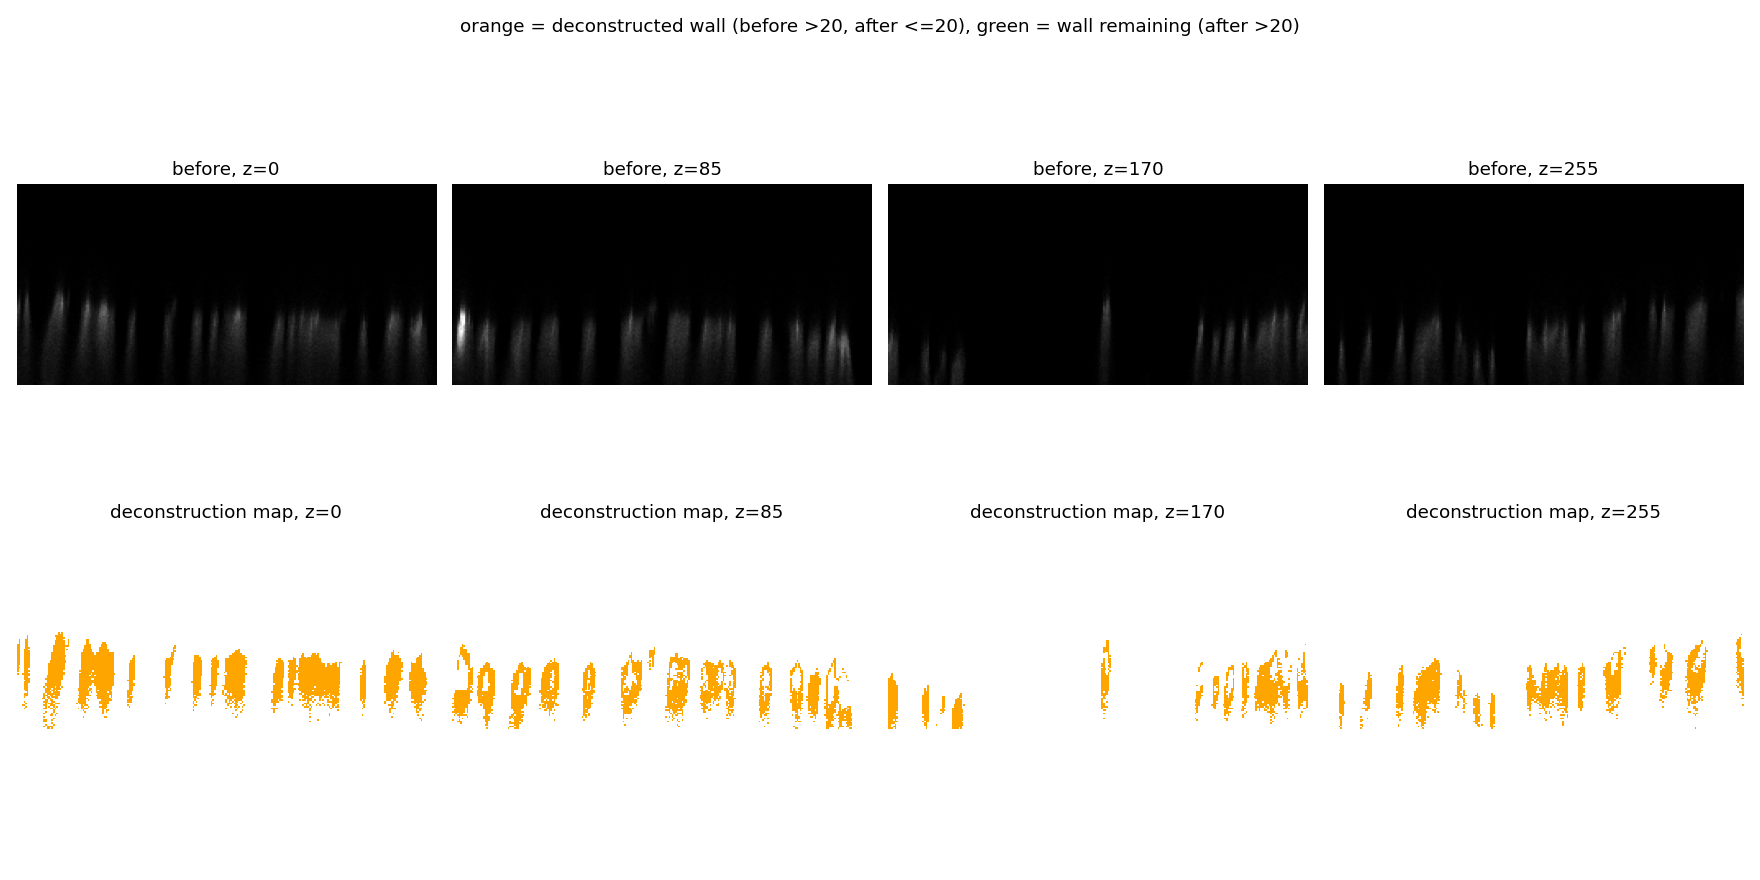

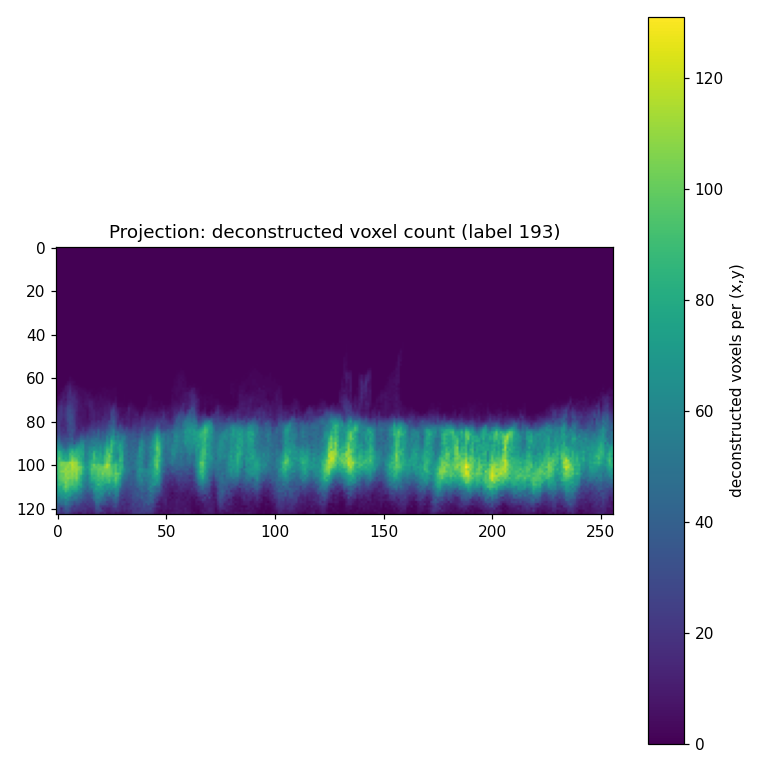

In [ ]:
from IPython.display import Image, display
display(Image(filename="/content/decon_slices.png"))
display(Image(filename="/content/decon_projection.png"))

## 8. Quantitative summary

Wall voxels and wall volume (voxel volume × wall count) at t0h vs t1h from the author pipeline's own outputs, plus the deconstructed fraction from the map of section 7 (both in the before-hydrolysis frame). The paper reports a significant wall-volume reduction after 24 h; this 2-point demo (1 h interval, no loading metadata) is only a mechanism demonstration — one example, not verification of the paper's statistics.

**定量的サマリー:** 著者パイプラインの出力から壁ボクセル数・体積の変化を集計します（1例のみで統計的検証ではありません）。

In [ ]:
driver = r'''
import sys
sys.path.insert(0, "/content/walltrack/WallTrack_src")
import numpy as np
from bmtiff import bmimread, getVoxelDimensions

def wall_volume(f):
    img, info = bmimread(f)
    vox = getVoxelDimensions(f)
    labels = img > 1  # non-background labeled walls (background label = 1)
    return int(labels.sum()), float(np.prod([v for v in vox if v]))

walls_t0 = "/content/results/wallSegmentations/t0h_walls_threhsold_14.tif"
walls_t1 = "/content/results/wallSegmentations/t1h_walls_threhsold_14.tif"
n0, v0 = wall_volume(walls_t0); n1, v1 = wall_volume(walls_t1)
data = np.load("/content/decon_data.npz")
before, decon = data["before"], data["decon"]
THRESH = 20
decon_vox = int(((data["after_reg"] <= THRESH) & (before > THRESH)).sum())
wall_t0_vox = int((before > THRESH).sum())
print(f"wall voxels  t0h: {n0:,}  t1h: {n1:,}")
print(f"wall volume  t0h: {n0*v0:.1f} um^3   t1h: {n1*v1:.1f} um^3")
print(f"wall voxels >20 (before frame): {wall_t0_vox:,}; deconstructed: {decon_vox:,} ({100*decon_vox/max(wall_t0_vox,1):.1f}%)")
'''
run_driver(driver, timeout=600)

wall voxels  t0h: 1,013,856  t1h: 372,802
wall volume  t0h: 159265.7 um^3   t1h: 58563.1 um^3
wall voxels >20 (before frame): 733,959; deconstructed: 598,072 (81.5%)



## 9. Interpretation, limitations, references

**What was executed (this run):** the pinned WallTrack pipeline on the authors' 2-stack demo dataset — empty-slice removal, seeded 3D watershed segmentation of the pre-hydrolysis stack, rigid→affine→vector-field registration onto the during-hydrolysis stack, segmentation propagation, wall/cell thresholding at 14, and the voxel deconstruction map (threshold 20) with matplotlib rendering. All outputs above are from this single Run-all execution.

**Limitations / 注意点:**
- Partial demonstration only: the paper's full 4D time-lapses, 0–20 FPU enzyme series, HPAEC-PAD conversion data, and cell-level statistics (volume/ASA/CNI correlations) use data not present in the public repository and are **not** reproduced here. One example does not verify published dataset-level results.
- The deconstruction-map **rendering** (jet colors instead of the BioModLab GUI) is an adapted visualization; the underlying voxel labeling follows `computeDeconstructionMap.py`.
- Author code is all-rights-reserved ("redistribution not permitted" header; no LICENSE file): it is run in place from the pinned clone, not redistributed. Publication of the author code itself would require the authors' permission.
- Voxel dimensions and thresholds are taken from the author TIFF tags and `dataNames.py` defaults; verify against your own datasets before reuse.

**References:** Refahi et al., *Bioresource Technology* 2024 / bioRxiv 2024.01.11.575220v1; WallTrack code, GitLab `farelab/teamyr/publications/refahi_et_al_4d` @ `c9df0f056432ca7e442d9391372f7ee4fdbbb2ba`; wiki (Installation, Segmentation); INRAE `vt-python` 1.1.0 (morpheme conda channel).